Four elemental tiles:

- Forest (Amazon)
- Desert (Sahara)
- Ice (Greenland)
- City (NYC)

Pulls embeddings from each location. Saves embeddings to geojson. Creates drawings for each embedding.


In [2]:
import base64
import ee
import json
import geopandas as gpd
import pyogrio
import re

from pathlib import Path
from shapely.geometry import Point

ee.Authenticate()
ee.Initialize(project="gsapp-map")

coords = {
    "nyc": [-73.990422, 40.729914],
    "amazon": [-62.566111, -3.135833],
    "greenland": [-58.489229, 75.864043],
    "sahara": [25.665556, 23.409444],
}

out_path = "element_embeddings.geojson"

In [ ]:
# Get 2024 embeddings for select locations.
# Save to a GeoJSON file.

band_names = [f"A{str(i).zfill(2)}" for i in range(64)]

dataset = (
    ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
    .filterDate("2024-01-01", "2025-01-01")
    .mosaic()
)

samples = []
for name, [lon, lat] in coords.items():
    try:
        sampled = (
            dataset.select(band_names)
            .sample(ee.Geometry.Point([lon, lat]), scale=10)
            .first()
            .getInfo()
        )
        embedding = [sampled["properties"].get(b, 0) for b in band_names]
        samples.append(
            {"name": name, "lon": lon, "lat": lat, "embedding": json.dumps(embedding)}
        )
    except Exception as e:
        print(f"Failed {name}: {e}")

gdf = gpd.GeoDataFrame(
    samples,
    geometry=[
        Point(xy)
        for xy in zip([s["lon"] for s in samples], [s["lat"] for s in samples])
    ],
    crs="EPSG:4326",
)

if "embedding" in gdf.columns:
    gdf["embedding"] = gdf["embedding"].apply(
        lambda arr: base64.b64encode(json.dumps(arr).encode("utf8")).decode("ascii")
    )


gdf.to_file(out_path, driver="GeoJSON")

print(f"Saved {len(gdf)} embeddings to {out_path}")

Saved 4 embeddings to element_embeddings.geojson


In [3]:
#  helper function to decode embeddings


def flatten_iter(x):
    if isinstance(x, (list, tuple)):
        for v in x:
            yield from flatten_iter(v)
    else:
        yield x


def try_json_loads(s):
    try:
        return json.loads(s)
    except Exception:
        return s


def decode_embedding(v):
    """Robustly decode embedding values saved as:
    - list/tuple
    - JSON string
    - base64(JSON string)
    - bytes
    Handles double-encoded values by attempting to parse repeatedly.
    """
    if v is None:
        return []
    # If already list/tuple, return as list
    if isinstance(v, (list, tuple)):
        return list(v)
    # If bytes, try decode then json
    if isinstance(v, bytes):
        try:
            decoded = v.decode("utf8")
        except Exception:
            return []
        v = decoded
    # If string, try base64 decode first (common in our write step)
    if isinstance(v, str):
        # attempt base64 decode if looks like base64 (rough test)
        b64_like = re.fullmatch(r"[A-Za-z0-9+/=\n\r]+", v.strip()) is not None
        if b64_like:
            try:
                raw = base64.b64decode(v)
                txt = raw.decode("utf8")
                parsed = try_json_loads(txt)
                if isinstance(parsed, str) and (
                    parsed.strip().startswith("[") or parsed.strip().startswith("{")
                ):
                    parsed2 = try_json_loads(parsed)
                    if parsed2 != parsed:
                        return parsed2
                return parsed
            except Exception:
                pass
        parsed = try_json_loads(v)
        if isinstance(parsed, str) and (
            parsed.strip().startswith("[") or parsed.strip().startswith("{")
        ):
            parsed2 = try_json_loads(parsed)
            return parsed2 if parsed2 != parsed else parsed
        return parsed
    return []

In [37]:
# vertical line drawings

# line color
color = "white"

# Create drawings directory
Path("drawings").mkdir(exist_ok=True)

# Read GeoJSON (pyogrio if available, else geopandas)
try:
    gdf = pyogrio.read_dataframe(out_path)
except Exception:
    gdf = gpd.read_file(out_path)

panels = []
for idx, row in gdf.iterrows():
    raw = decode_embedding(row.get("embedding"))
    # flatten and coerce to floats
    vals = []
    for item in flatten_iter(raw):
        try:
            vals.append(float(item))
        except Exception:
            continue

    # ensure exactly 64 bands
    if len(vals) > 64:
        vals = vals[:64]
    elif len(vals) < 64:
        vals = vals + [0.0] * (64 - len(vals))

    name = str(row.get("name", f"p{idx}"))
    if not vals:
        print(f"Skipping {name}: empty embedding after parsing")
        continue

    # drawing params
    band_count = len(vals)
    title_h = 28
    band_h = 14
    padding = 8
    width = 200
    sat_height = 200
    height = title_h + sat_height + band_count * band_h + padding

    # region for the trace: place to the right of text values
    trace_x0 = 0  # left edge of trace area (moved left)
    trace_w = (width - trace_x0 - 12) * 1.2  # range

    labels = [f"{v:.3f}" for v in vals]

    # compute traced x positions mapped from [-1, 1]
    xs = []
    for v in vals:
        # clip to [-1,1]
        vv = max(-1.0, min(1.0, v))
        # normalized 0..1
        t = (vv + 1.0) / 2.0
        x = trace_x0 + t * trace_w
        xs.append(x)

    svg = [
        f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg" '
        'xmlns:xlink="http://www.w3.org/1999/xlink">'
    ]

    # title centered
    svg.append(
        f'<text x="6" y="{title_h - 8}" font-size="14" fill="{color}">{coords[name]}</text>'
    )

    # --- add satellite image ---
    # sat_path = f"satellite/{name}.png"
    # if not Path(sat_path).exists():
    #     print(f"  [WARNING] Satellite image not found: {sat_path}")

    # svg.append(
    #     f'<image href="{sat_path}" x="0" y="{title_h}" width="{width}" height="{sat_height}"/>'
    # )
    # adjust all subsequent content down by sat_height
    y_offset = title_h + sat_height

    # write text labels down the left
    for i, text in enumerate(labels):
        y = y_offset + i * band_h + 12
        svg.append(f'<text x="6" y="{y}" font-size="11" fill="{color}">{text}</text>')

    # build polyline points (trace) top-to-bottom
    points = []
    for i, x in enumerate(xs):
        y = y_offset + i * band_h + 10  # align with text baseline roughly
        points.append(f"{x:.2f},{y:.2f}")
    points_str = " ".join(points)
    svg.append(
        f'<polyline points="{points_str}" fill="none" stroke="{color}" stroke-width="1.2" />'
    )

    svg.append("</svg>")

    svg_path = Path(f"drawings/{name}_{color}.svg")
    svg_path.write_text("\n".join(svg))
    print(f"Created {svg_path}")

    panels.append({"svg": svg, "w": width, "h": height, "name": name})

# combined all.svg
if panels:
    spacing = 12
    total_w = sum(p["w"] for p in panels) + spacing * (len(panels) - 1)
    max_h = max(p["h"] for p in panels)
    all_svg = [
        f'<svg width="{total_w}" height="{max_h}" xmlns="http://www.w3.org/2000/svg">'
    ]
    # all_svg.append('<rect width="100%" height="100%" fill="white"/>')

    x = 0
    for p in panels:
        content = "\n".join(p["svg"])
        lines = content.split("\n")
        inner = "\n".join(lines[1:-1]) if len(lines) > 2 else ""
        # wrap panel in group translated to x
        all_svg.append(f'<g transform="translate({x},0)">')
        all_svg.append(inner)
        # # add panel title again in combined (absolute centered in panel)
        # all_svg.append(
        #     f'<text x="{x + p["w"]/2}" y="{title_h - 8}" font-size="14" fill="{color}" text-anchor="middle">{p["name"]}</text>'
        # )
        all_svg.append("</g>")
        x += p["w"] + spacing

    all_svg.append("</svg>")
    all_path = Path(f"drawings/all_{color}.svg")
    all_path.write_text("\n".join(all_svg))
    print(f"Created {all_path}")

ValueError: could not convert string to float: 'wLjA5ODQyMzY4MzE5ODc2OTcxLCAtMC4yMDY5MzU3OTM5MjU0MTMzLCAwLjA4ODgyNzM3NDA4Njg4OTY1LCAtMC4xNTM3ODcwMDQ5OTgwNzc2NSwgMC4wMDQ5ODI2OTg5NjE5Mzc3MTYsIC0wLjE5OTg2MTU5MTY5NTUwMTc0LCAwLjA1OTExNTcyNDcyMTI2MTA1LCAtMC4wMjQ2MDU5MjA3OTk2OTI0MjcsIC0wLjI1MTk2NDYyODk4ODg1MDQsIDAuMDE3Nzc3Nzc3Nzc3Nzc3Nzc4LCAtMC4wMjcxMjgwMjc2ODE2NjA5LCAwLjA1OTExNTcyNDcyMTI2MTA1LCAtMC4wMDE1Mzc4NzAwNDk5ODA3NzY3LCAtMC4xMjQ1Njc0NzQwNDg0NDI5MywgLTAuMjA2OTM1NzkzOTI1NDEzMywgLTAuMTI0NTY3NDc0MDQ4NDQyOTMsIDAuMTUzNzg3MDA0OTk4MDc3NjUsIDAuMjI4ODk2NTc4MjM5MTM4OCwgMC4wMTAzOTYwMDE1Mzc4NzAwNDksIDAuMDM4NDQ2NzUxMjQ5NTE5NDEsIDAuMTE5MDkyNjU2NjcwNTExMzMsIDAuMDk4NDIzNjgzMTk4NzY5NzEsIC0wLjE4NjA4MjI3NjA0NzY3NCwgMC4wNTkxMTU3MjQ3MjEyNjEwNSwgMC4wOTM1NjQwMTM4NDA4MzA0NiwgMC4wOTM1NjQwMTM4NDA4MzA0NiwgMC4wMTIwNTY5MDExOTE4NDkyODgsIC0wLjAzODQ0Njc1MTI0OTUxOTQxLCAwLjE0MTczMDEwMzgwNjIyODM2LCAtMC4wMjQ2MDU5MjA3OTk2OTI0MjcsIC0wLjAwODg1ODEzMTQ4Nzg4OTI3MiwgLTAuMDE5OTMwNzk1ODQ3NzUwODY0LCAtMC4wMzg0NDY3NTEyNDk1MTk0MSwgLTA

In [ ]:
# Download 500m x 500m satellite images for each location
from pathlib import Path
import urllib.request


Path("satellite").mkdir(exist_ok=True)

# Sentinel-2 imagery (10m resolution, RGB)
dataset = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterDate(
    "2024-01-01", "2025-01-01"
)

for name, [lon, lat] in coords.items():
    pt = ee.Geometry.Point([lon, lat])
    # 250m buffer = 500m x 500m region
    region = pt.buffer(250)

    # Get best (least cloudy) image
    try:
        image = dataset.filterBounds(region).sort("CLOUDY_PIXEL_PERCENTAGE").first()

        # Extract RGB bands
        rgb = image.select(["B4", "B3", "B2"])

        # Create thumbnail URL: 512x512 pixels covering 500m x 500m
        url = rgb.getThumbURL(
            {"min": 0, "max": 3000, "dimensions": 512, "region": region}
        )

        # Download image
        img_path = f"satellite/{name}.png"
        urllib.request.urlretrieve(url, img_path)
        print(f"✓ Downloaded {img_path}")
    except Exception as e:
        print(f"✗ Failed {name}: {e}")

✓ Downloaded satellite/nyc.png
✓ Downloaded satellite/amazon.png
✓ Downloaded satellite/amazon.png
✓ Downloaded satellite/greenland.png
✓ Downloaded satellite/greenland.png
✓ Downloaded satellite/sahara.png
✓ Downloaded satellite/sahara.png


[[-0.13544135 -0.49980512 -0.55025196]
 [ 0.877812    0.19591902  0.046551  ]
 [-0.25898257 -0.4134453   0.5708106 ]
 [-0.48338792  0.7173315  -0.06710975]]


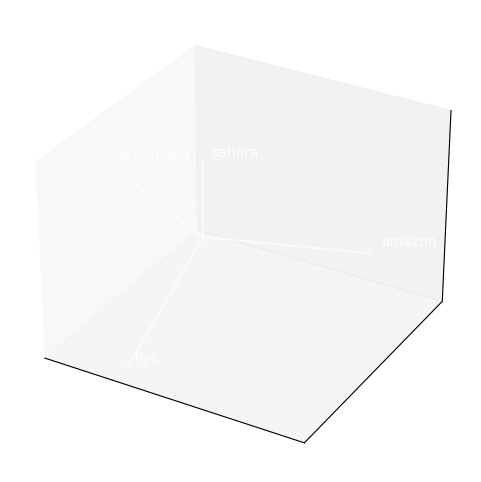

In [5]:
import geopandas as gpd
import numpy as np
import umap
import matplotlib.pyplot as plt
import pyogrio
import json
import base64
import re
from sklearn.decomposition import PCA

# --- Read GeoJSON ---
out_path = "element_embeddings.geojson"

try:
    gdf = pyogrio.read_dataframe(out_path)
except Exception:
    gdf = gpd.read_file(out_path)

# --- Extract embeddings ---
emb_list = []
names = []

for idx, row in gdf.iterrows():
    raw = decode_embedding(row.get("embedding"))
    vals = []
    for item in flatten_iter(raw):
        try:
            vals.append(float(item))
        except Exception:
            continue
    # pad/truncate to 64
    vals = vals[:64] if len(vals) > 64 else vals + [0.0] * (64 - len(vals))
    emb_list.append(vals)
    names.append(str(row.get("name", f"p{idx}")))

emb_arr = np.array(emb_list, dtype=np.float32)  # shape (4,64)

# --- PCA to 3D ---
# emb_arr shape is (4, 64)
pca = PCA(n_components=3)
emb_3d = pca.fit_transform(emb_arr)

print(emb_3d)

# --- Plot 3D vectors ---
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

for i, vec in enumerate(emb_3d):
    ax.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], color="white", alpha=0.7)
    offset = 0.04 * np.linalg.norm(vec)
    ax.text(vec[0] + offset, vec[1] + offset, vec[2] + offset, names[i], color="white")

# transparent background
fig.patch.set_alpha(0)
ax.set_facecolor((0, 0, 0, 0))
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.savefig("drawings/vectorgraph.svg", transparent=True)

plt.show()